In [3]:
import  pandas as pd
import numpy as np
df1 = pd.read_csv('/content/train.csv')
df2 = pd.read_csv('/content/transactions.csv')
df3 = pd.read_csv('/content/stores.csv')
df4 = pd.read_csv('/content/oil.csv')
df5 = pd.read_csv('/content/holidays_events.csv')
df1.shape

(3000888, 6)

In [4]:
df1 = df1.merge(df2,
                on  = ['date','store_nbr'],
                how='left')
df1 = df1.merge(df3,
                on  = ['store_nbr'],
                how='left')
df1 = df1.merge(df4,
                on  = ['date'],
                how='left')

In [5]:
print("Rows before merge:", len(pd.read_csv("/content/train.csv")))
print("Rows after merge:", len(df1))

Rows before merge: 3000888
Rows after merge: 3000888


In [85]:
df1.head(5)

,id,date,store_nbr,family,sales,onpromotion,transactions,city,state,type,cluster,dcoilwtico
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,Quito,Pichincha,D,13,NaN
1,1,2013-01-01,1,BABY CARE,0.0,0,NaN,Quito,Pichincha,D,13,NaN
2,2,2013-01-01,1,BEAUTY,0.0,0,NaN,Quito,Pichincha,D,13,NaN
3,3,2013-01-01,1,BEVERAGES,0.0,0,NaN,Quito,Pichincha,D,13,NaN
4,4,2013-01-01,1,BOOKS,0.0,0,NaN,Quito,Pichincha,D,13,NaN


In [6]:
from os.path import join
#National
national=df5[df5['locale']=='National'].copy()
national_summary = (national.groupby('date').agg({'description':','.join,'type':','.join,'transferred':'max'})).reset_index()
national_summary=national_summary.rename(columns={'description':"National_Holiday",'type':'National_Holiday_Type','transferred':'National_transferred'})
#Regional
regional=df5[df5['locale']=='Regional'].copy()
regional_summary= (regional.groupby(['date','locale_name']).agg({'description':','.join,'type':','.join,'transferred':'max'})).reset_index()
regional_summary=regional_summary.rename(columns={'locale_name':'state','description':"Regional_Holiday",'type':'Regional_Holiday_Type','transferred':'Regional_transferred'})
#Local
local = df5[df5['locale']=='Local'].copy()
local_summary= (local.groupby(['date','locale_name']).agg({'description':','.join,'type':','.join,'transferred':'max'})).reset_index()
local_summary=local_summary.rename(columns={'locale_name':'city','description':"Local_Holiday",'type':'Local_Holiday_Type','transferred':'Local_transferred'})

In [7]:
df1 = df1.merge(national_summary,on=['date'],how='left') #Merging National

In [8]:
df1 = df1.merge(regional_summary,on=['date','state'],how='left') #Merging Regional

In [9]:
df1 = df1.merge(local_summary,on=['date','city'],how='left') #Merging Local

In [10]:
df1.shape

(3000888, 21)

In [ ]:
df1.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion',
       'transactions', 'city', 'state', 'type', 'cluster', 'dcoilwtico',
       'National_Holiday', 'National_Holiday_Type', 'National_transferred',
       'Regional_Holiday', 'Regional_Holiday_Type', 'Regional_transferred',
       'Local_Holiday', 'Local_Holiday_Type', 'Local_transferred'],
      dtype='object')

In [ ]:
df1.head(5) #Final Dataset


,id,date,store_nbr,family,sales,onpromotion,transactions,city,state,type,...,dcoilwtico,National_Holiday,National_Holiday_Type,National_transferred,Regional_Holiday,Regional_Holiday_Type,Regional_transferred,Local_Holiday,Local_Holiday_Type,Local_transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,Quito,Pichincha,D,...,NaN,Primer dia del ano,Holiday,False,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2013-01-01,1,BABY CARE,0.0,0,NaN,Quito,Pichincha,D,...,NaN,Primer dia del ano,Holiday,False,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2013-01-01,1,BEAUTY,0.0,0,NaN,Quito,Pichincha,D,...,NaN,Primer dia del ano,Holiday,False,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2013-01-01,1,BEVERAGES,0.0,0,NaN,Quito,Pichincha,D,...,NaN,Primer dia del ano,Holiday,False,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2013-01-01,1,BOOKS,0.0,0,NaN,Quito,Pichincha,D,...,NaN,Primer dia del ano,Holiday,False,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
#filling null values
import warnings
warnings.filterwarnings('ignore')
df1['National_Holiday']= df1['National_Holiday'].fillna('No_Holiday')
df1['National_Holiday_Type']= df1['National_Holiday_Type'].fillna('No_Holiday')
df1['National_transferred']= df1['National_transferred'].fillna(False)
df1['Regional_Holiday']= df1['Regional_Holiday'].fillna('No_Holiday')
df1['Regional_Holiday_Type']= df1['Regional_Holiday_Type'].fillna('No_Holiday')
df1['Regional_transferred']= df1['Regional_transferred'].fillna(False)
df1['Local_Holiday']= df1['Local_Holiday'].fillna('No_Holiday')
df1['Local_Holiday_Type']= df1['Local_Holiday_Type'].fillna('No_Holiday')
df1['Local_transferred']= df1['Local_transferred'].fillna(False)
df1.isnull().sum()
#For remaining NULL VALUES WE USE SIMPLE IMPUTER
#IF I USE SIMPLE IMPUTER FOR FILLING NULL VALUES FOR NATIONAL ,REGIONAL AND LOCAL IT LEADS TO HAVING SAME FESTIVAL ON DIFFERENT DATES


,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0
transactions,245784
city,0
state,0
type,0


In [12]:
df1 = df1.drop('id',axis=1)

In [13]:
df1 = df1.sort_values(['store_nbr','family','date']).copy()
df1.head(5)

,date,store_nbr,family,sales,onpromotion,transactions,city,state,type,cluster,dcoilwtico,National_Holiday,National_Holiday_Type,National_transferred,Regional_Holiday,Regional_Holiday_Type,Regional_transferred,Local_Holiday,Local_Holiday_Type,Local_transferred
0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,Quito,Pichincha,D,13,NaN,Primer dia del ano,Holiday,False,No_Holiday,No_Holiday,False,No_Holiday,No_Holiday,False
1782,2013-01-02,1,AUTOMOTIVE,2.0,0,2111.0,Quito,Pichincha,D,13,93.14,No_Holiday,No_Holiday,False,No_Holiday,No_Holiday,False,No_Holiday,No_Holiday,False
3564,2013-01-03,1,AUTOMOTIVE,3.0,0,1833.0,Quito,Pichincha,D,13,92.97,No_Holiday,No_Holiday,False,No_Holiday,No_Holiday,False,No_Holiday,No_Holiday,False
5346,2013-01-04,1,AUTOMOTIVE,3.0,0,1863.0,Quito,Pichincha,D,13,93.12,No_Holiday,No_Holiday,False,No_Holiday,No_Holiday,False,No_Holiday,No_Holiday,False
7128,2013-01-05,1,AUTOMOTIVE,5.0,0,1509.0,Quito,Pichincha,D,13,NaN,Recupero puente Navidad,Work Day,False,No_Holiday,No_Holiday,False,No_Holiday,No_Holiday,False


In [14]:
df1['date'] = pd.to_datetime(df1['date'])
cutoff_date = pd.Timestamp('2017-07-31')
train  = df1[df1['date']<=cutoff_date]
test = df1[df1['date']>cutoff_date]
train.head(5)

,date,store_nbr,family,sales,onpromotion,transactions,city,state,type,cluster,dcoilwtico,National_Holiday,National_Holiday_Type,National_transferred,Regional_Holiday,Regional_Holiday_Type,Regional_transferred,Local_Holiday,Local_Holiday_Type,Local_transferred
0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,Quito,Pichincha,D,13,NaN,Primer dia del ano,Holiday,False,No_Holiday,No_Holiday,False,No_Holiday,No_Holiday,False
1782,2013-01-02,1,AUTOMOTIVE,2.0,0,2111.0,Quito,Pichincha,D,13,93.14,No_Holiday,No_Holiday,False,No_Holiday,No_Holiday,False,No_Holiday,No_Holiday,False
3564,2013-01-03,1,AUTOMOTIVE,3.0,0,1833.0,Quito,Pichincha,D,13,92.97,No_Holiday,No_Holiday,False,No_Holiday,No_Holiday,False,No_Holiday,No_Holiday,False
5346,2013-01-04,1,AUTOMOTIVE,3.0,0,1863.0,Quito,Pichincha,D,13,93.12,No_Holiday,No_Holiday,False,No_Holiday,No_Holiday,False,No_Holiday,No_Holiday,False
7128,2013-01-05,1,AUTOMOTIVE,5.0,0,1509.0,Quito,Pichincha,D,13,NaN,Recupero puente Navidad,Work Day,False,No_Holiday,No_Holiday,False,No_Holiday,No_Holiday,False


In [15]:
train = train.sort_values(
    ['store_nbr', 'family', 'date']
).copy()

train['lag_1'] = (
    train.groupby(['store_nbr', 'family'])['sales']
    .shift(1)
)

train['lag_7'] = (
    train.groupby(['store_nbr', 'family'])['sales']
    .shift(7)
)

train['lag_14'] = (
    train.groupby(['store_nbr', 'family'])['sales']
    .shift(14)
)

In [16]:
train['ewm_7'] = (
    train.groupby(['store_nbr', 'family'])['sales']
    .transform(
        lambda x: x.shift(1)
        .ewm(span=7, adjust=False)
        .mean()
    )
)

train['ewm_14'] = (
    train.groupby(['store_nbr', 'family'])['sales']
    .transform(
        lambda x: x.shift(1)
        .ewm(span=14, adjust=False)
        .mean()
    )
)

In [ ]:
train.head(5)

,date,store_nbr,family,sales,onpromotion,transactions,city,state,type,cluster,...,Regional_Holiday_Type,Regional_transferred,Local_Holiday,Local_Holiday_Type,Local_transferred,lag_1,lag_7,lag_14,ewm_7,ewm_14
0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,Quito,Pichincha,D,13,...,No_Holiday,False,No_Holiday,No_Holiday,False,NaN,NaN,NaN,NaN,NaN
1782,2013-01-02,1,AUTOMOTIVE,2.0,0,2111.0,Quito,Pichincha,D,13,...,No_Holiday,False,No_Holiday,No_Holiday,False,0.0,NaN,NaN,0.00000,0.000000
3564,2013-01-03,1,AUTOMOTIVE,3.0,0,1833.0,Quito,Pichincha,D,13,...,No_Holiday,False,No_Holiday,No_Holiday,False,2.0,NaN,NaN,0.50000,0.266667
5346,2013-01-04,1,AUTOMOTIVE,3.0,0,1863.0,Quito,Pichincha,D,13,...,No_Holiday,False,No_Holiday,No_Holiday,False,3.0,NaN,NaN,1.12500,0.631111
7128,2013-01-05,1,AUTOMOTIVE,5.0,0,1509.0,Quito,Pichincha,D,13,...,No_Holiday,False,No_Holiday,No_Holiday,False,3.0,NaN,NaN,1.59375,0.946963


In [ ]:
df1.dtypes

,0
date,datetime64[ns]
store_nbr,int64
family,object
sales,float64
onpromotion,int64
transactions,float64
city,object
state,object
type,object
cluster,int64


             city                           state       sales
0           Quito                       Pichincha  556.577090
1         Cayambe                       Pichincha  509.709179
2          Ambato                      Tungurahua  362.632273
3           Daule                          Guayas  345.282181
4            Loja                            Loja  339.379530
5        Babahoyo                        Los Rios  319.349181
6         Machala                          El Oro  300.392253
7      Esmeraldas                      Esmeraldas  294.963151
8          Cuenca                           Azuay  294.924279
9       Guayaquil                          Guayas  276.594464
10       Libertad                          Guayas  275.722146
11        Quevedo                        Los Rios  255.137503
12       Guaranda                         Bolivar  234.821670
13  Santo Domingo  Santo Domingo de los Tsachilas  214.942315
14         Ibarra                        Imbabura  206.061866
15      

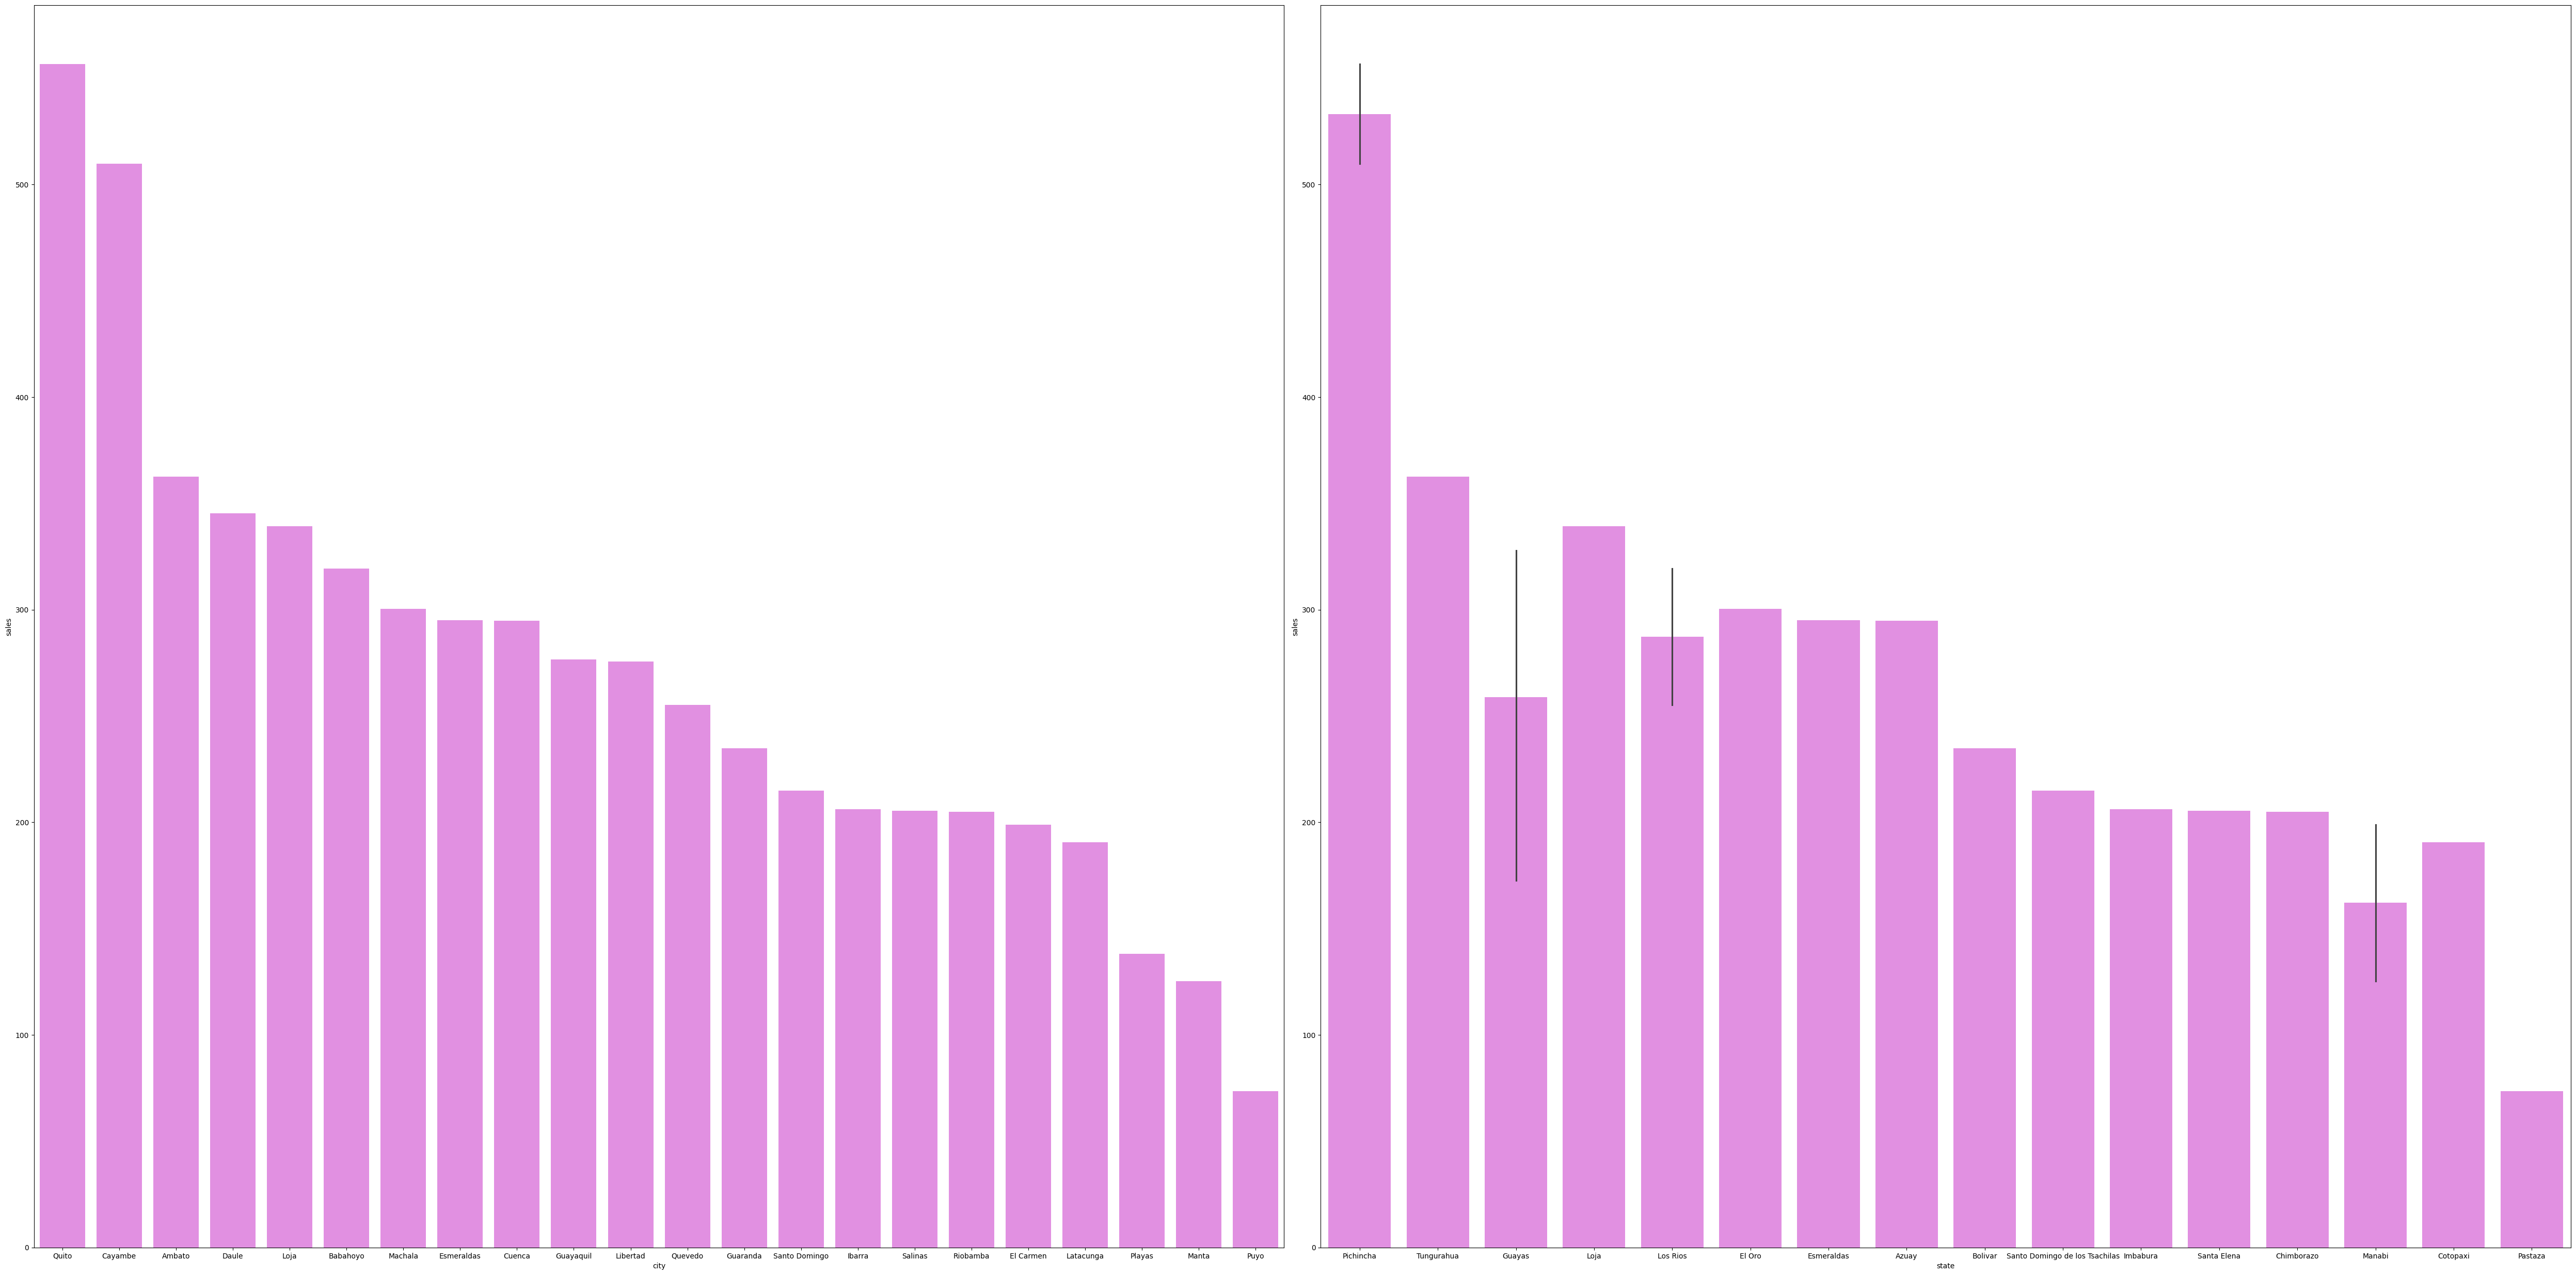

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
df  = df1.copy()
plt.figure(figsize=(50,49))
plt.subplot(2,2,1)
city_sales=df1.groupby(['city','state'])['sales'].mean().sort_values(ascending=False).reset_index()
print(city_sales)
sns.barplot(x='city',y='sales',data=city_sales,color='violet')
plt.subplot(2,2,2)
sns.barplot(x='state',y='sales',data=city_sales,color='violet')
plt.tight_layout()
plt.show()
#avg sales per each city and state

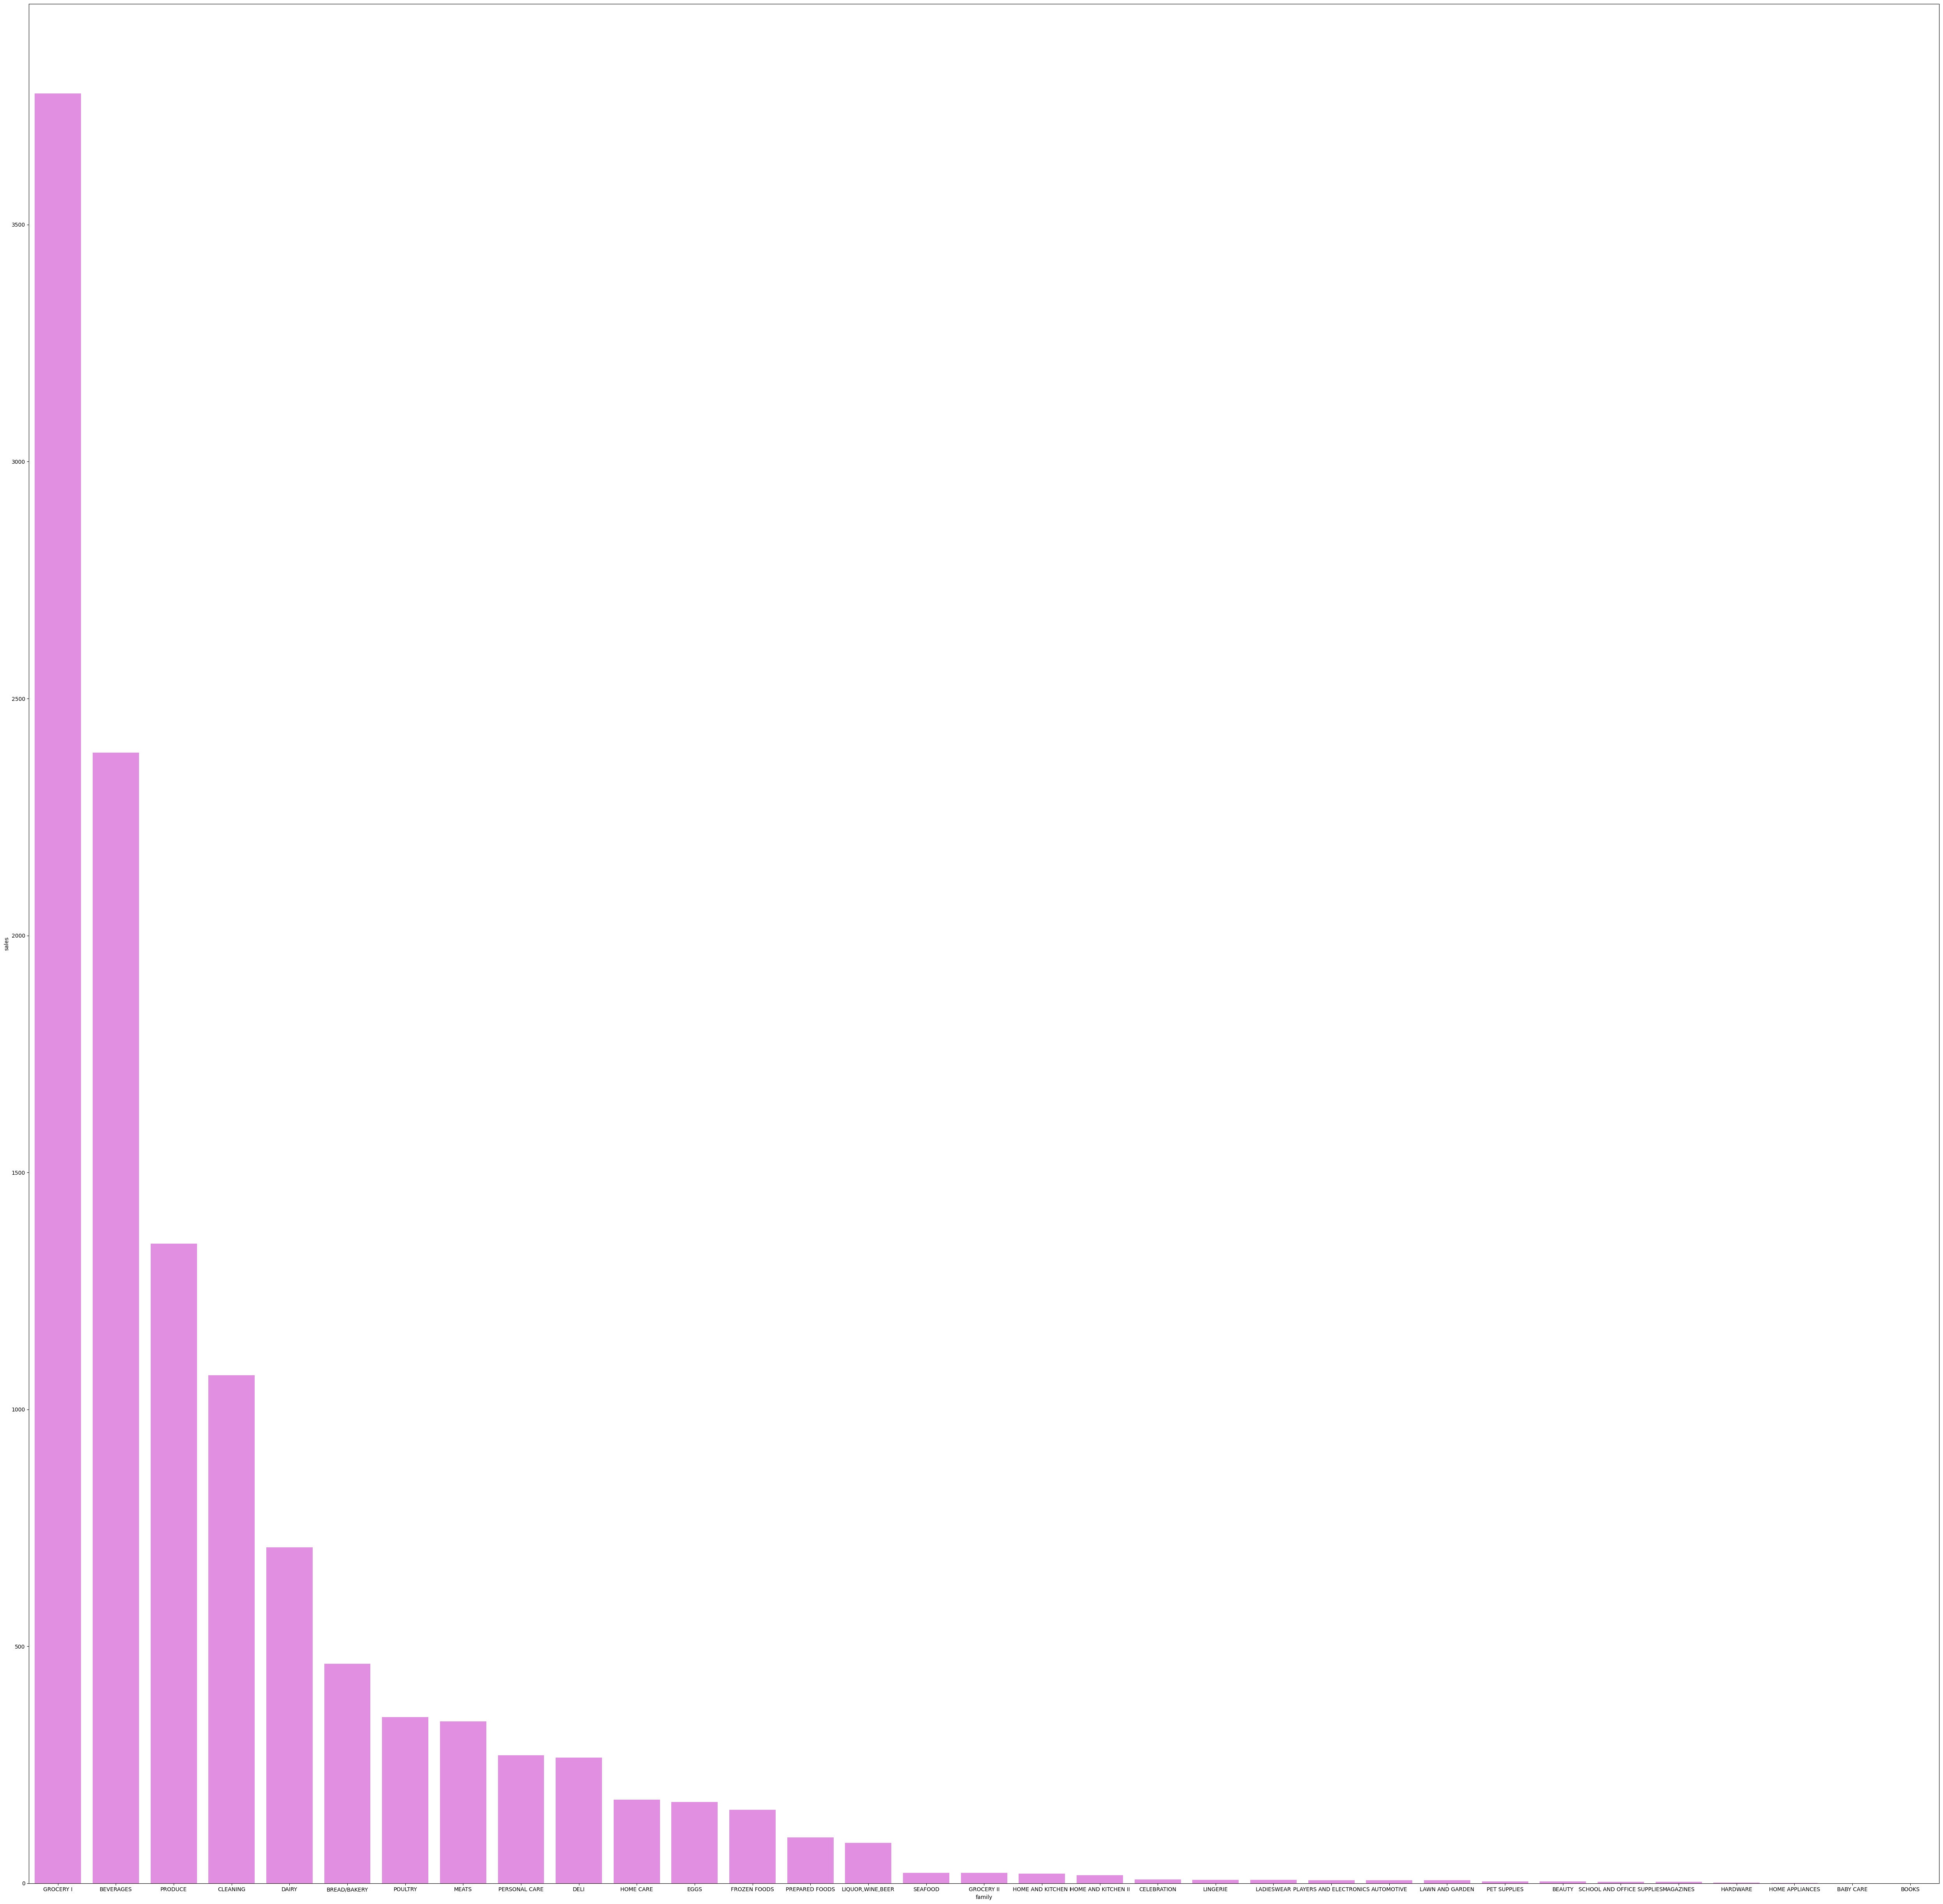

,family,sales
0,GROCERY I,3776.972100
1,BEVERAGES,2385.793151
2,PRODUCE,1349.352123
3,CLEANING,1072.416744
4,DAIRY,709.154889
5,BREAD/BAKERY,463.336254
6,POULTRY,350.532292
7,MEATS,341.849965
8,PERSONAL CARE,270.432513
9,DELI,265.135067


In [ ]:
family_sales=df1.groupby(['family'])['sales'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(50,49))
sns.barplot(x='family',y='sales',data=family_sales,color='violet') #avg sales for  each family
plt.tight_layout()
plt.show()
family_sales


<Axes: >

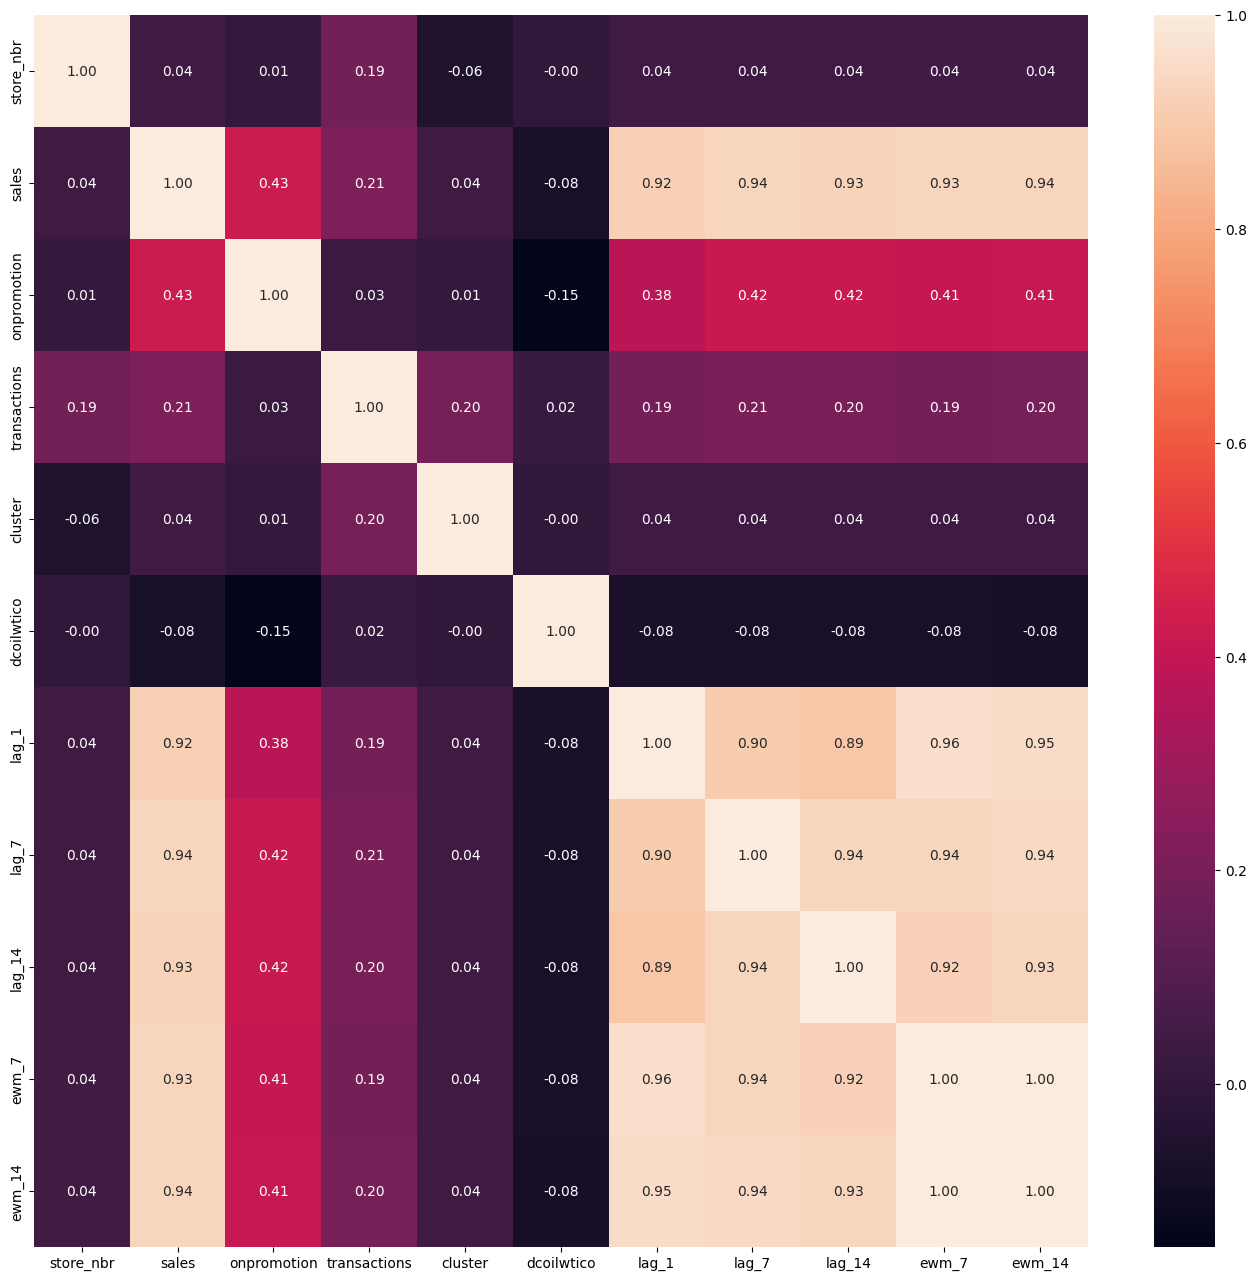

In [ ]:
plt.figure(figsize=(17,16))
sns.heatmap(train.select_dtypes(include=['int64','float64']).corr(),annot=True,fmt='.2f')

In [ ]:
national_holiday_sales=df1.groupby(['National_Holiday','Local_Holiday','city'])['sales'].mean().sort_values(ascending=False).reset_index()
national_holiday_sales['city'].unique() #To know on which National Holidays sales are increasing
#'Ambato', 'Libertad', 'Salinas', 'Riobamba', 'Machala', 'Latacunga', 'Puyo'
 #    These are the Cities where NATIONAL HOLIDAY AND LOCAL HOLIDAY ARE CONTRIBUTING MORE TO SALES WHICH ARE ON SAME DATE

array(['Ambato', 'Libertad', 'Salinas', 'Riobamba', 'Machala',
       'Latacunga', 'Puyo'], dtype=object)

In [ ]:
df1.groupby(['state','Regional_Holiday'])['sales'].mean().sort_values(ascending=False).reset_index() #Regional Holidays are not present for many states ,So sales can be incresed from LOCAL HOLIDAYS AND NATIONAL HOLIDAYS


,state,Regional_Holiday,sales
0,Santo Domingo de los Tsachilas,Provincializacion de Santo Domingo,264.017609
1,Cotopaxi,Provincializacion de Cotopaxi,234.051215
2,Santa Elena,Provincializacion Santa Elena,182.504114
3,Imbabura,Provincializacion de Imbabura,176.549758


In [ ]:
df1.groupby(['city','Local_Holiday'])['sales'].mean().sort_values(ascending=False).reset_index()


,city,Local_Holiday,sales
0,Quito,Fundacion de Quito,786.600770
1,Quito,Fundacion de Quito-1,609.518621
2,Cayambe,Cantonizacion de Cayambe,445.602558
3,Loja,Fundacion de Loja,441.522932
4,Ambato,Independencia de Ambato,359.330708
5,Ambato,Fundacion de Ambato,325.854186
6,Esmeraldas,Fundacion de Esmeraldas,313.340643
7,Guayaquil,"Fundacion de Guayaquil-1,Traslado Fundacion de...",303.655909
8,Machala,Fundacion de Machala,288.350188
9,Cuenca,Fundacion de Cuenca,288.061103


In [ ]:
national_holiday_sales=df1.groupby(['National_Holiday','city'])['sales'].mean().sort_values(ascending=False).reset_index()
national_holiday_sales #NATIONAL HOLIDAY INCREASING SALES

,National_Holiday,city,sales
0,Traslado Primer dia del ano,Quito,1324.689581
1,Terremoto Manabi+1,Quito,1233.286544
2,Terremoto Manabi+1,Daule,1215.212818
3,Terremoto Manabi+2,Quito,1186.848767
4,"Dia del Trabajo,Terremoto Manabi+15",Quito,1164.354720
...,...,...,...
1579,Recupero puente Navidad,Manta,0.000000
1580,Recupero puente Navidad,Puyo,0.000000
1581,Recupero Puente Navidad,Puyo,0.000000
1582,"Puente Navidad,Navidad+1",Puyo,0.000000


In [ ]:
df1.groupby(['Local_Holiday','city'])['sales'].mean().sort_values(ascending=False).reset_index()

#from this observation I can conclude SALES mainly depend on NATIOANAL OR LOCAL HOLIDAY OR REGIONAL HOLIDAY BUT NOT ON THE NAME OF NATIONAL,LOCAL AND REGIONAL HOLIDAY

,Local_Holiday,city,sales
0,Fundacion de Quito,Quito,786.600770
1,Fundacion de Quito-1,Quito,609.518621
2,No_Holiday,Quito,555.901755
3,No_Holiday,Cayambe,509.900086
4,Cantonizacion de Cayambe,Cayambe,445.602558
5,Fundacion de Loja,Loja,441.522932
6,No_Holiday,Ambato,362.727928
7,Independencia de Ambato,Ambato,359.330708
8,No_Holiday,Daule,345.282181
9,No_Holiday,Loja,339.136332


In [ ]:
                                      #Final Observations
# Sales are INCRESING DUE TO NATIONAL HOLIDAY
# sales are INCREASING DUE TO COMBINATION OF NATIONAL HOLIDAY AND LOCAL HOLIDAY OR LOCAL HOLIDAY ALONE
#sales are not THAT MUCH INCREASING DUE TO REGIONAL HOLIDAYS BECAUSE ONLY SOME STATES HAVE REGIONAL HOLIDAYS AND INCRESE IN SALES IS MAINLY
#DUE TO NATIONAL AND LOCAL HOLIDAY IN EACH STATE RESPECTIVELY

In [ ]:
print(df1.groupby(['National_transferred'])['sales'].mean().sort_values(ascending=False))
df1.groupby(['National_Holiday_Type'])['sales'].mean().sort_values(ascending=False)
#Holiday and Event combinely generating more sales

National_transferred
False    419.339289
True     281.197453
Name: sales, dtype: float64


,sales
National_Holiday_Type,
"Holiday,Event",712.750397
"Additional,Event",601.118281
Additional,520.019819
"Bridge,Additional",489.393073
Transfer,474.340800
"Event,Event",460.619887
Bridge,425.429744
Event,415.420292
Work Day,372.157524


In [ ]:
print(df1.groupby(['Local_transferred'])['sales'].mean().sort_values(ascending=False))
df1.groupby(['Local_Holiday_Type'])['sales'].mean().sort_values(ascending=False)
#Additional Hoolidays for Local Festivals increses the SALES

Local_transferred
False    427.115047
True     353.676218
Name: sales, dtype: float64


,sales
Local_Holiday_Type,
Additional,502.783108
Transfer,422.578768
Holiday,397.130580
"Additional,Transfer",303.655909


In [ ]:
df1.isnull().sum()
print(df1.groupby(['Regional_transferred'])['sales'].mean().sort_values(ascending=False))
df1.groupby(['Regional_Holiday_Type'])['sales'].mean().sort_values(ascending=False)

Regional_transferred
False    229.725442
Name: sales, dtype: float64


,sales
Regional_Holiday_Type,
Holiday,229.725442


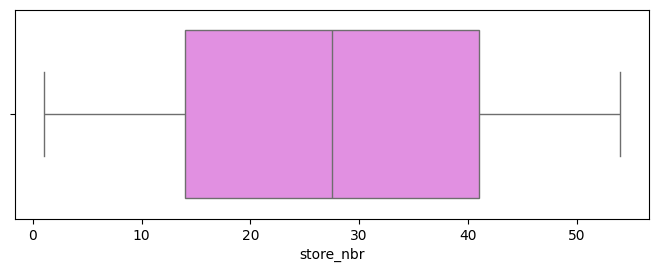

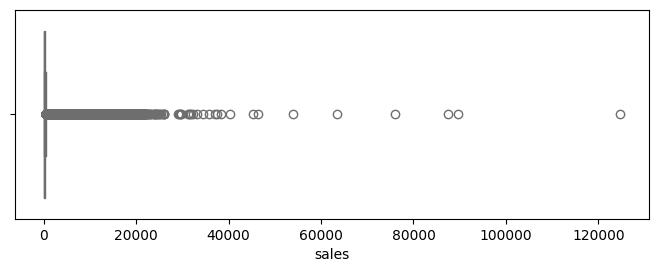

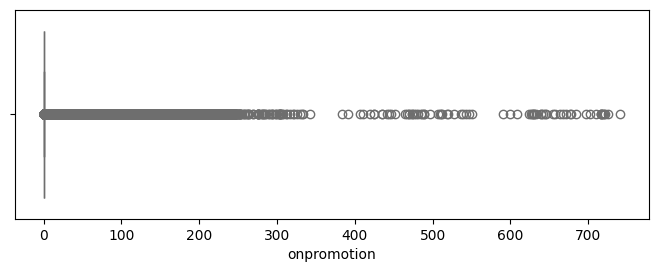

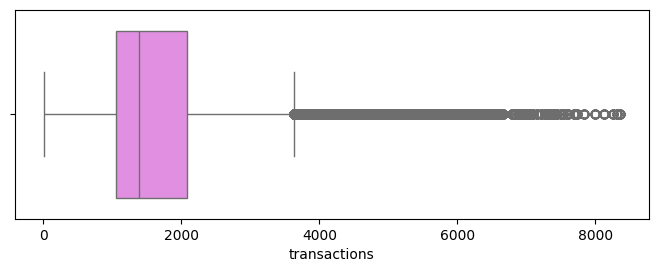

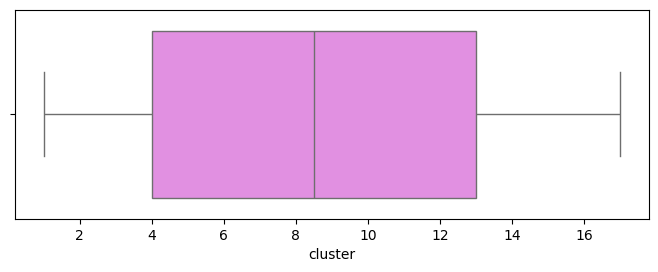

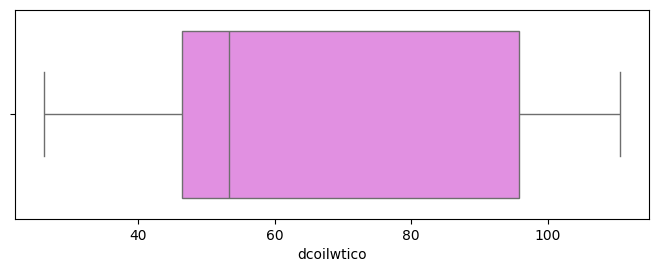

In [61]:
import seaborn as sns
num = df1.select_dtypes(include=['int64','float64']).columns
for i,col in enumerate(num):
  plt.figure(figsize=(18,19))
  plt.subplot(len(num),2,2*i+1)
  sns.boxplot(x=df1[col],data = df1,color='violet')


In [ ]:
df1.select_dtypes(include=['int64','float64']).skew()
#to apply Power transformer

,0
store_nbr,0.000000
sales,7.358758
onpromotion,11.166562
transactions,1.518325
cluster,0.040087
dcoilwtico,0.303349


In [17]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV,cross_val_score,TimeSeriesSplit
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer,OrdinalEncoder,OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor



In [ ]:
train.select_dtypes(include='int64').columns

Index(['store_nbr', 'onpromotion', 'cluster'], dtype='object')

In [22]:
train =  train.drop(['National_Holiday','Regional_Holiday','Local_Holiday'],axis =1)
class outliercapper(BaseEstimator,TransformerMixin):
  def fit(self,x,y=None):
    q1 = np.percentile(x,25,axis=0)
    q3 = np.percentile(x,75,axis=0)
    self.lower = q1-1.5*(q3-q1)
    self.upper = q3+1.5*(q3-q1)
    return self
  def transform(self,x):
    x = np.clip(x,self.lower,self.upper)
    return x
  def get_feature_names_out(self,input_features=None):
    return input_features

num_pipe =  Pipeline([('impute',SimpleImputer())])
ohe_pipe = Pipeline([('Ohe',OneHotEncoder(sparse_output=True,handle_unknown='ignore'))])
preprocessor= ColumnTransformer([('num',num_pipe,['onpromotion','transactions','dcoilwtico','lag_1', 'lag_7', 'lag_14',
       'ewm_7', 'ewm_14']),
     ('ohe_p',ohe_pipe,train.select_dtypes(include='object').columns.tolist())],remainder='passthrough')



In [23]:
train.columns

Index(['date', 'store_nbr', 'family', 'sales', 'onpromotion', 'transactions',
       'city', 'state', 'type', 'cluster', 'dcoilwtico',
       'National_Holiday_Type', 'National_transferred',
       'Regional_Holiday_Type', 'Regional_transferred', 'Local_Holiday_Type',
       'Local_transferred', 'lag_1', 'lag_7', 'lag_14', 'ewm_7', 'ewm_14'],
      dtype='object')

In [25]:
train_sample= train.tail(90000)
train_sample = train_sample.sort_values('date').copy()
y_sample = train_sample['sales']
x_sample = train_sample.drop(columns=['date','sales'],axis =1)
tscv = TimeSeriesSplit(n_splits=2)
from sklearn.model_selection import train_test_split
main_pipe_1= Pipeline([('preprocessor',preprocessor),('model',XGBRegressor())])
params = [{'model':[RandomForestRegressor()],
           'model__n_estimators': [200, 300],
    'model__max_depth': [10, 15]
    },{
        'model':[XGBRegressor()],
        'model__n_estimators': [ 300, 500],
    'model__learning_rate': [0.01,0.05],
    'model__max_depth': [ 6, 8],
        'model__reg_alpha': [0, 0.1],
    'model__reg_lambda': [1, 5]

    }]
grid = RandomizedSearchCV(estimator=main_pipe_1,param_distributions=params,cv=tscv,scoring='neg_root_mean_squared_error',n_jobs=-1)
grid.fit(x_sample,y_sample)
print(grid.best_score_)
print(grid.best_params_)


-190.56114804302632
{'model__n_estimators': 300, 'model__max_depth': 10, 'model': RandomForestRegressor()}


In [26]:
best_model = grid.best_estimator_
best_model.set_params(model__n_jobs=-1)
train_f = train.tail(800000)
x_f = train_f.drop(['sales'],axis=1)
y_f = train_f['sales']




In [27]:
x_f = x_f.drop(['date'],axis=1)
best_model.fit(x_f,y_f)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer())]),
                                                  ['onpromotion',
                                                   'transactions', 'dcoilwtico',
                                                   'lag_1', 'lag_7', 'lag_14',
                                                   'ewm_7', 'ewm_14']),
                                                 ('ohe_p',
                                                  Pipeline(steps=[('Ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['family', 'city', 'state',
                                                   'type',
                                                   'National_Holiday_Type',
                                                   'Regional_Holiday_Type',
                                                   'Local_Holiday_Type'])])),
                ('model',
                 RandomForestRegressor(max_depth=10, n_estimators=300,
                                       n_jobs=-1))])

In [44]:
history = train[
    ['store_nbr', 'family', 'date', 'sales']
].copy()

history = history.sort_values(
    ['store_nbr', 'family', 'date']
).copy()



In [45]:
test_s = test.sort_values(
    ['date', 'store_nbr', 'family']
).copy()
y_test = test_s['sales'].copy()


In [46]:
forecast_dates = sorted(
    test_s['date'].unique()
)

predictions = []

In [47]:
history_df = history.copy()
history = {}
for (store_nbr, family), group in history_df.groupby(['store_nbr', 'family']):
    history[(store_nbr, family)] = group['sales'].tolist()

for current_date in forecast_dates:

    # All observations for one day
    current_rows = test_s[
        test_s['date'] == current_date
    ].copy()


    # =========================================
    # START WITH ORIGINAL TEST FEATURES
    # =========================================

    X_current = current_rows.drop(
        ['sales', 'date'],
        axis=1
    ).copy()


    # Lists to store temporal features
    lag_1_list = []
    lag_7_list = []
    lag_14_list = []

    ewm_7_list = []
    ewm_14_list = []


    # =========================================
    # CALCULATE TEMPORAL FEATURES
    # =========================================

    for _, row in current_rows.iterrows():

        key = (
            row['store_nbr'],
            row['family']
        )

        past_sales = history[key]


        # -------- LAGS --------

        lag_1_list.append(
            past_sales[-1]
            if len(past_sales) >= 1
            else np.nan
        )

        lag_7_list.append(
            past_sales[-7]
            if len(past_sales) >= 7
            else np.nan
        )

        lag_14_list.append(
            past_sales[-14]
            if len(past_sales) >= 14
            else np.nan
        )


        # -------- EWM --------

        sales_series = pd.Series(past_sales)

        ewm_7_list.append(
            sales_series
            .ewm(span=7, adjust=False)
            .mean()
            .iloc[-1]
        )

        ewm_14_list.append(
            sales_series
            .ewm(span=14, adjust=False)
            .mean()
            .iloc[-1]
        )


    # =========================================
    # ADD TEMPORAL FEATURES
    # =========================================

    X_current['lag_1'] = lag_1_list
    X_current['lag_7'] = lag_7_list
    X_current['lag_14'] = lag_14_list

    X_current['ewm_7'] = ewm_7_list
    X_current['ewm_14'] = ewm_14_list


    # =========================================
    # SAME FEATURE ORDER AS TRAINING
    # =========================================

    X_current = X_current[x_sample.columns]


    # =========================================
    # PREDICT ALL ROWS OF THIS DAY AT ONCE
    # =========================================

    current_predictions = best_model.predict(
        X_current
    )


    # Store predictions
    predictions.extend(current_predictions)


    # =========================================
    # UPDATE HISTORY WITH PREDICTIONS
    # =========================================

    for (_, row), prediction in zip(
        current_rows.iterrows(),
        current_predictions
    ):

        key = (
            row['store_nbr'],
            row['family']
        )

        history[key].append(prediction)

In [48]:
y_pred = np.array(predictions)
print("Actual observations:", len(y_test))
print("Predictions:", len(y_pred))

Actual observations: 26730
Predictions: 26730


In [49]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

final_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

final_r2 = r2_score(
    y_test, y_pred
)

print("Final Recursive RMSE:", final_rmse)
print("Final Recursive R²:", final_r2)

Final Recursive RMSE: 279.6467557460905
Final Recursive R²: 0.9494896179787264


In [50]:
high_demand_threshold = np.percentile(y_test, 90)

high_demand_mask = y_test >= high_demand_threshold

high_demand_rmse = np.sqrt(
    mean_squared_error(
        y_test[high_demand_mask],
        y_pred[high_demand_mask]
    )
)

print("Overall RMSE:", final_rmse)
print("High-demand threshold:", high_demand_threshold)
print("High-demand RMSE:", high_demand_rmse)
print("Number of high-demand observations:", high_demand_mask.sum())

Overall RMSE: 279.6467557460905
High-demand threshold: 1195.0
High-demand RMSE: 842.8551736863534
Number of high-demand observations: 2674


In [51]:
#Feature Importance
preprocessor=  best_model.named_steps['preprocessor']
feature_names=preprocessor.get_feature_names_out()
feature_names= [name.split('__')[-1] for name in feature_names]
xgb= best_model.named_steps['model']
importance= pd.DataFrame({'feature_names':feature_names,'importance':xgb.feature_importances_})
importance['importance'].sort_values(ascending=False)

,importance
6,0.716277
4,0.203549
1,0.025396
5,0.022466
3,0.019158
...,...
71,0.000000
73,0.000000
76,0.000000
80,0.000000


In [52]:
importance= importance.sort_values(by='importance',ascending = False)
importance.iloc[0:30,:]


,feature_names,importance
6,ewm_7,0.716277
4,lag_7,0.203549
1,transactions,0.025396
5,lag_14,0.022466
3,lag_1,0.019158
0,onpromotion,0.002814
2,dcoilwtico,0.002026
7,ewm_14,0.001723
66,National_Holiday_Type_Holiday,0.001620
77,store_nbr,0.000946


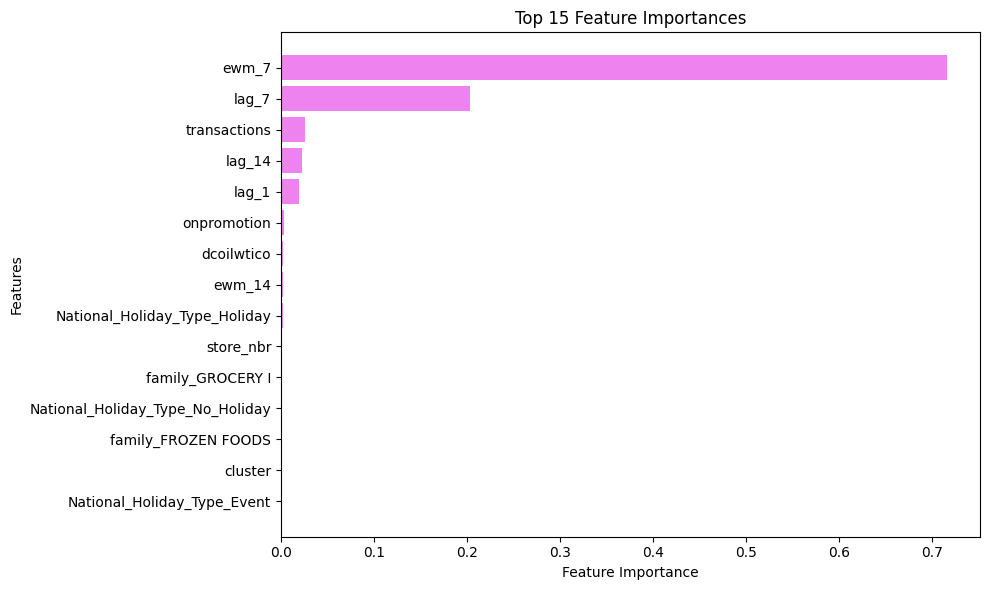

In [54]:
# Sort features by importance
importance_sorted = importance.sort_values(
    by='importance',
    ascending=False
)

# Select top 15 features
top_features = importance_sorted.head(15)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['feature_names'],
    top_features['importance'],color='violet'
)

plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 15 Feature Importances')

# Highest importance at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

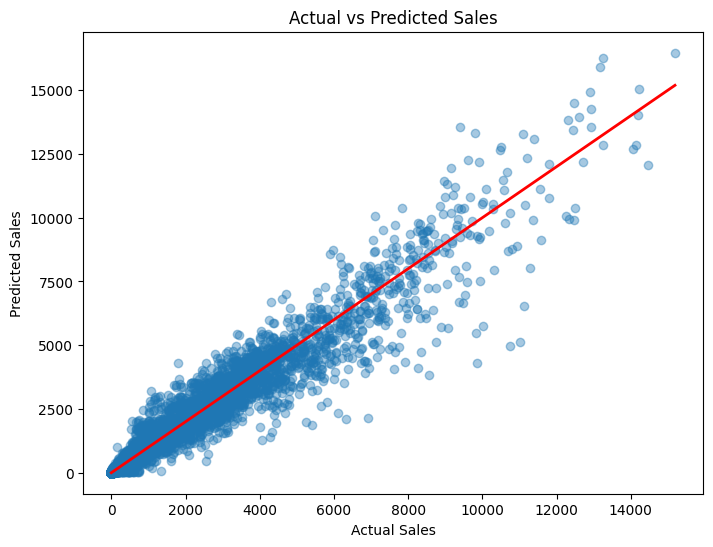

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()


In [ ]:
#The Actual vs Predicted plot shows that the model predicts most low- and medium-sales observations accurately, as many points lie close to the ideal prediction line.
#However, for a small number of observations with extremely high sales, the model tends to underestimate the actual values.
#This suggests that while the model generalizes well overall, it has difficulty capturing rare peak-sales events.

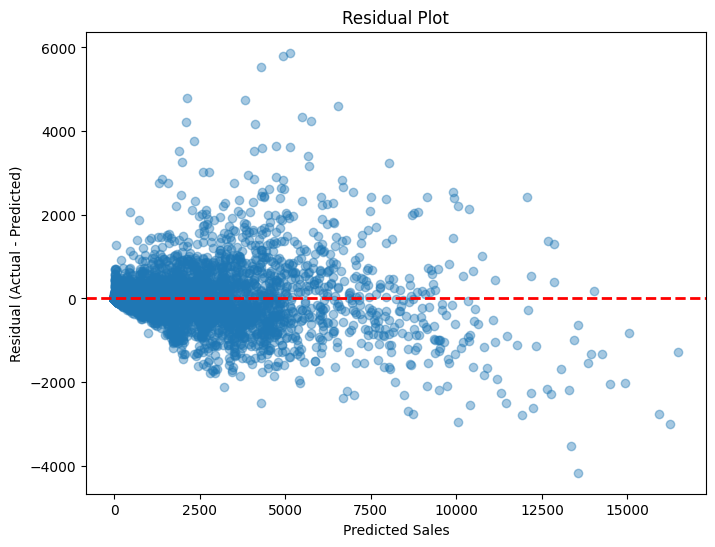

In [58]:
residual = y_test-y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residual, alpha=0.4)

plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")

plt.show()

In [ ]:
#The residual plot shows that most residuals are centered around zero, indicating that the model predicts the majority of observations accurately.
#However, a few observations exhibit very large positive residuals, suggesting that the model underestimates rare high-sales events.
#This behavior is consistent with the Actual vs Predicted plot and indicates that while the model performs well overall, predicting extreme peak sales remains challenging.

In [59]:
!pip freeze > requirements.txt